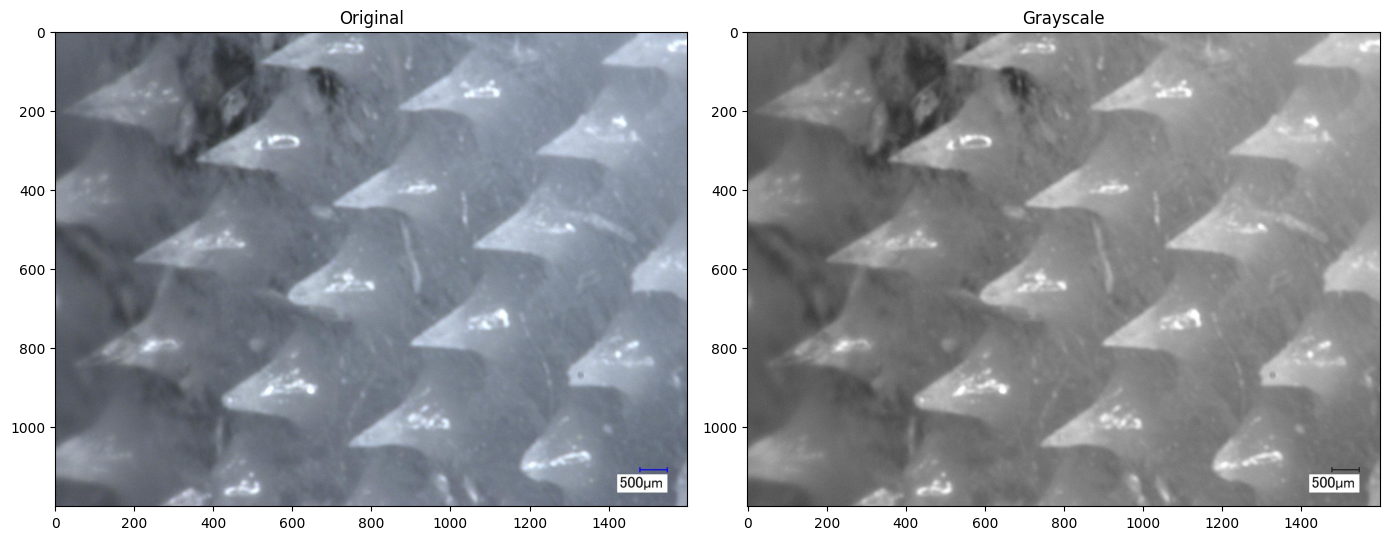

画像サイズ: (1200, 1600)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 画像パスを指定（analysis.ipynbからの相対パス）
IMAGE_PATH = "../images/sample.jpg"  # ← 画像ファイルを入れる場所

# 画像読み込み
img_bgr = cv2.imread(IMAGE_PATH)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 表示
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grayscale")
plt.tight_layout()
plt.show()

print(f"画像サイズ: {img_gray.shape}")  # (高さ, 幅)

高さ: 1200px, 幅: 1600px


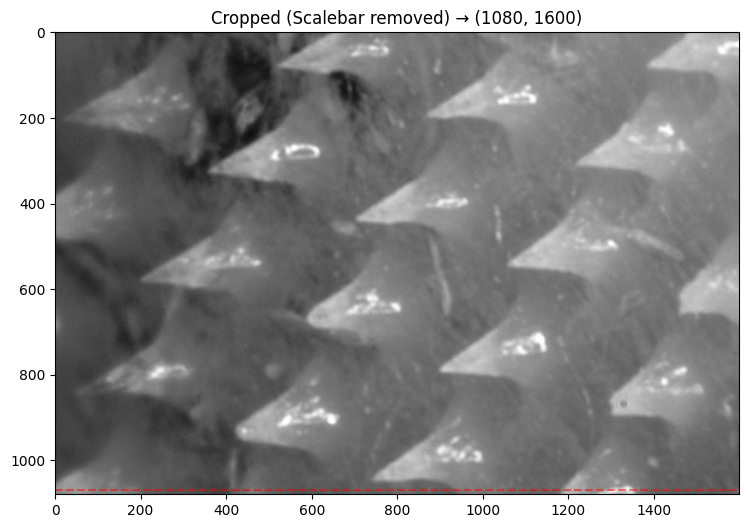

In [2]:
# 画像の高さ・幅を取得
h, w = img_gray.shape
print(f"高さ: {h}px, 幅: {w}px")

# スケールバーが写っている下部領域をマスク（除外）
# 画像下部10%をカット（後で調整可能）
crop_bottom = int(h * 0.90)
img_cropped = img_gray[:crop_bottom, :]

# 確認表示
plt.figure(figsize=(10, 6))
plt.imshow(img_cropped, cmap='gray')
plt.title(f"Cropped (Scalebar removed) → {img_cropped.shape}")
plt.axhline(y=crop_bottom-10, color='red', linestyle='--', alpha=0.5)
plt.show()

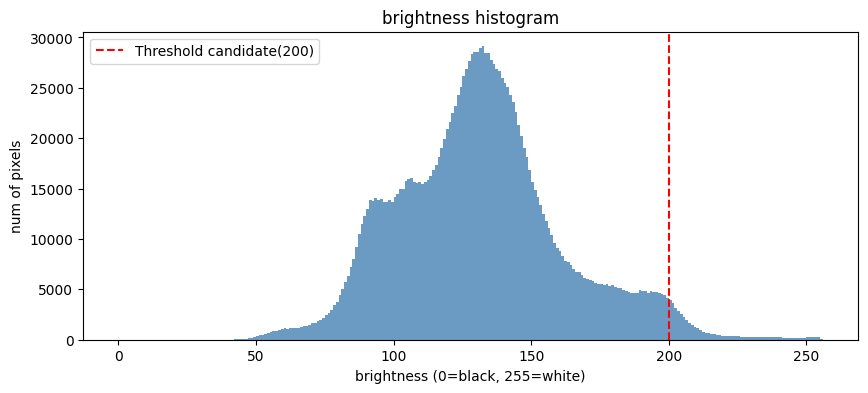

In [3]:
# ヒストグラムで画像全体の明るさ分布を確認
plt.figure(figsize=(10, 4))
plt.hist(img_cropped.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
plt.xlabel("brightness (0=black, 255=white)")
plt.ylabel("num of pixels")
plt.title("brightness histogram")
plt.axvline(x=200, color='red', linestyle='--', label='Threshold candidate(200)')
plt.legend()
plt.show()

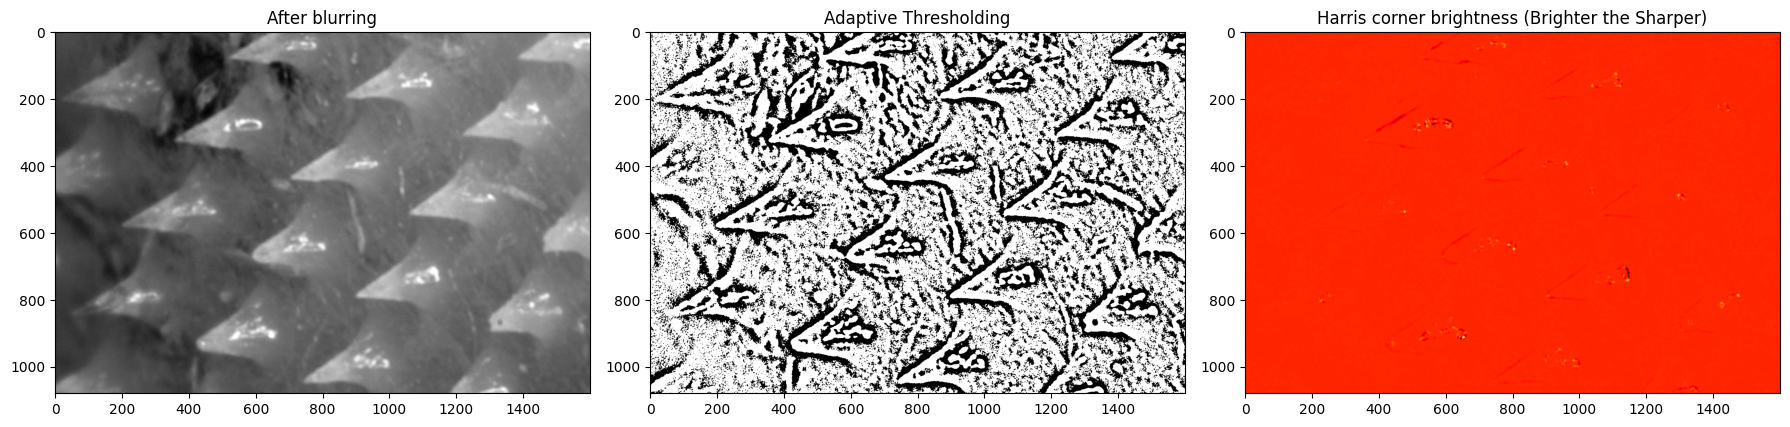

In [4]:
# ガウシアンブラーでノイズ除去
img_blur = cv2.GaussianBlur(img_cropped, (5, 5), 0)

# 適応的二値化（照明ムラに強い）
img_binary = cv2.adaptiveThreshold(
    img_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=51,
    C=2
)

# Harrisコーナー検出（尖った頂点を探す）
img_float = np.float32(img_blur)
harris = cv2.cornerHarris(img_float, blockSize=7, ksize=3, k=0.04)
harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 表示
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_blur, cmap='gray')
axes[0].set_title("After blurring")
axes[1].imshow(img_binary, cmap='gray')
axes[1].set_title("Adaptive Thresholding")
axes[2].imshow(harris_norm, cmap='hot')
axes[2].set_title("Harris corner brightness (Brighter the Sharper)")
plt.tight_layout()
plt.show()

# [FAILED] Harris corner detection - too much noise, switching to contour approach

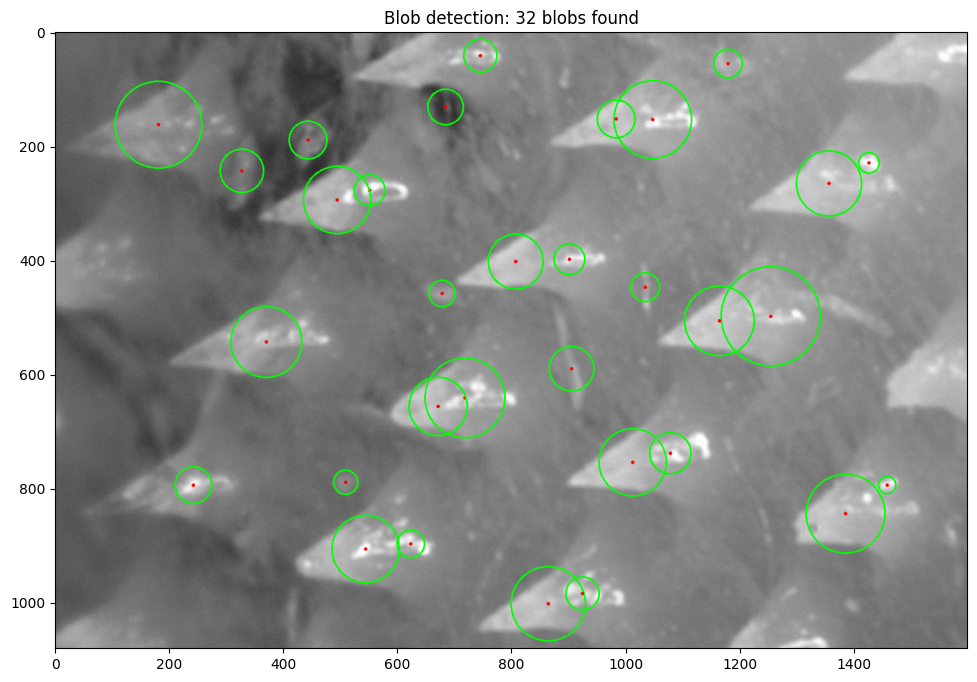

Detected: 32 blobs


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Blob detector parameters
params = cv2.SimpleBlobDetector_Params()

# Filter by area (adjust based on needle size in pixels)
params.filterByArea = True
params.minArea = 500
params.maxArea = 50000

# Filter by circularity (cones are not circular, so keep loose)
params.filterByCircularity = False

# Filter by convexity
params.filterByConvexity = True
params.minConvexity = 0.5

# Filter by inertia (elongated shapes)
params.filterByInertia = False

# Detect on inverted image (blobs = dark regions between cones)
img_inv = cv2.bitwise_not(img_cropped)

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(img_inv)

# Draw detected blobs
img_with_blobs = cv2.cvtColor(img_cropped, cv2.COLOR_GRAY2BGR)
for kp in keypoints:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = int(kp.size / 2)
    cv2.circle(img_with_blobs, (x, y), r, (0, 255, 0), 2)
    cv2.circle(img_with_blobs, (x, y), 3, (0, 0, 255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_with_blobs, cv2.COLOR_BGR2RGB))
plt.title(f"Blob detection: {len(keypoints)} blobs found")
plt.show()

print(f"Detected: {len(keypoints)} blobs")

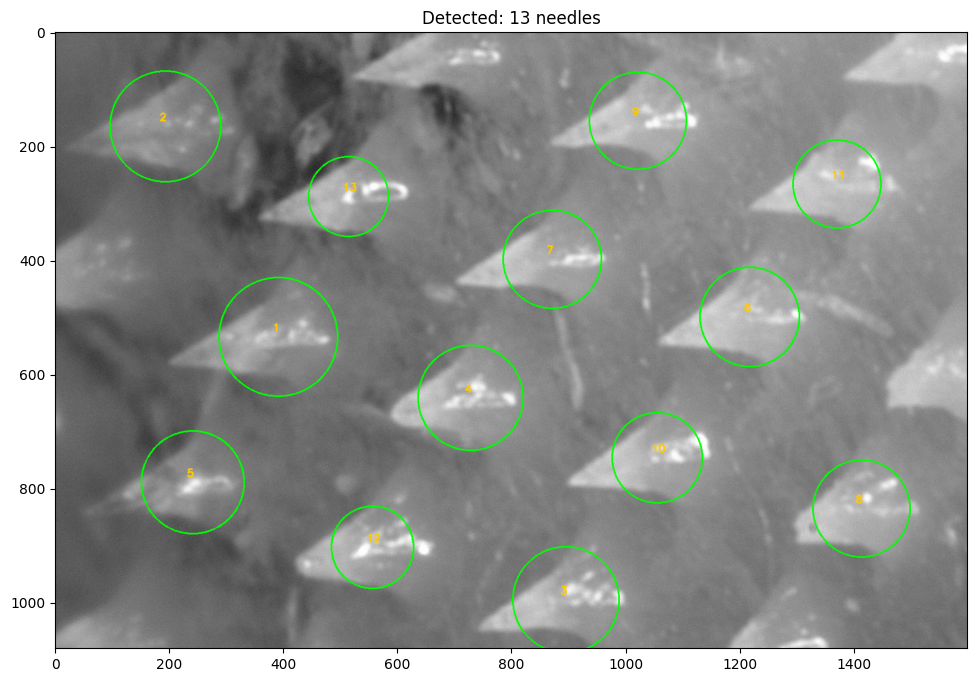

Before NMS: 13, After NMS: 13


In [6]:
# Non-Maximum Suppression (NMS) - 近すぎるblobを統合する
def remove_duplicates(keypoints, min_distance=50):
    """中心間距離がmin_distance以下のblobは近い方を削除"""
    if len(keypoints) == 0:
        return keypoints
    
    pts = np.array([kp.pt for kp in keypoints])
    sizes = np.array([kp.size for kp in keypoints])
    keep = []
    suppressed = set()
    
    # 大きいblobを優先して残す
    order = np.argsort(-sizes)
    
    for i in order:
        if i in suppressed:
            continue
        keep.append(i)
        for j in order:
            if i == j or j in suppressed:
                continue
            dist = np.linalg.norm(pts[i] - pts[j])
            if dist < min_distance:
                suppressed.add(j)
    
    return [keypoints[i] for i in keep]

# パラメータ調整版
params2 = cv2.SimpleBlobDetector_Params()

params2.filterByArea = True
params2.minArea = 11000    # 小さすぎるblobを除外（上げると検出数が減る）
params2.maxArea = 60000

params2.filterByConvexity = True
params2.minConvexity = 0.5

detector2 = cv2.SimpleBlobDetector_create(params2)
keypoints2 = detector2.detect(img_inv)

# ダブり除去
keypoints_filtered = remove_duplicates(keypoints2, min_distance=90)

# 描画
img_result = cv2.cvtColor(img_cropped, cv2.COLOR_GRAY2BGR)
for i, kp in enumerate(keypoints_filtered):
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = int(kp.size / 2)
    cv2.circle(img_result, (x, y), r, (0, 255, 0), 2)
    cv2.putText(img_result, str(i+1), (x-10, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected: {len(keypoints_filtered)} needles")
plt.show()

print(f"Before NMS: {len(keypoints2)}, After NMS: {len(keypoints_filtered)}")

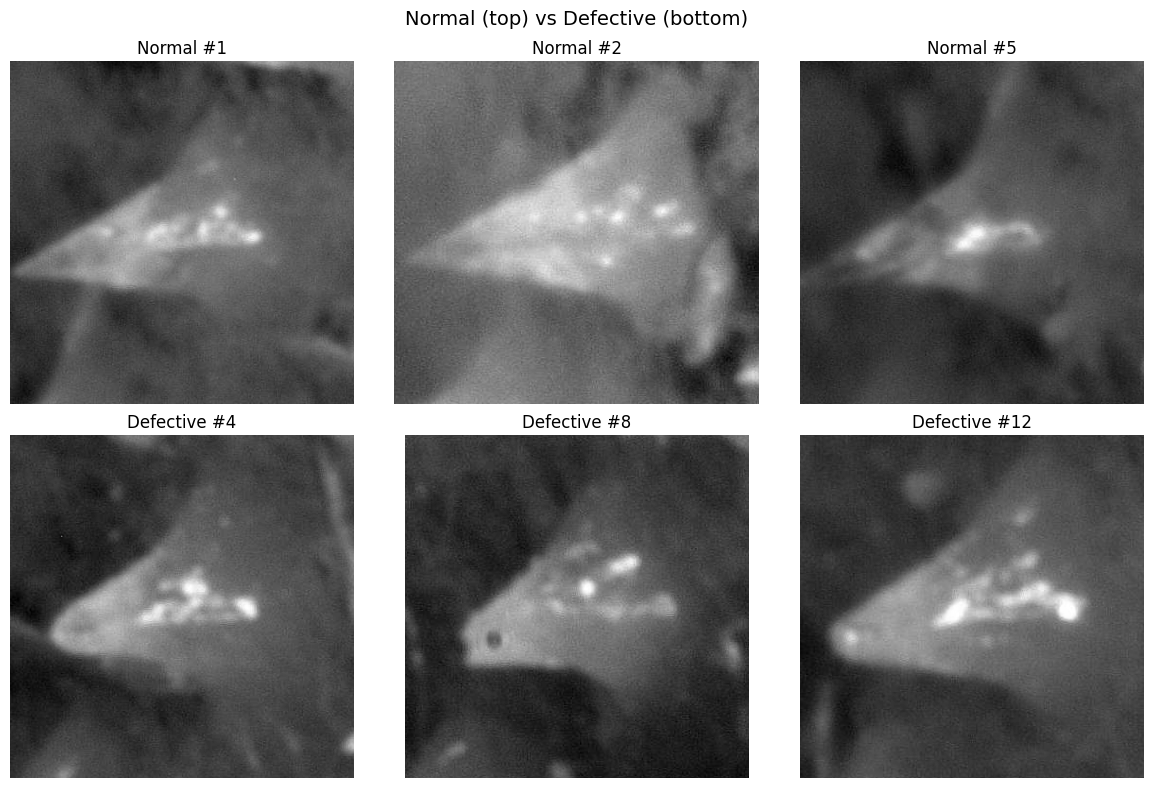

In [18]:
defective = [4, 8, 12]  # 欠損針の番号（1-indexed）
normal = [1, 2, 5]      # 比較用の正常針

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for col, idx in enumerate(normal):
    kp = keypoints_filtered[idx - 1]
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = int(kp.size / 2) + 90  # 少し余白を持って切り出す
    crop = img_cropped[max(0,y-r):y+r, max(0,x-r):x+r]
    axes[0, col].imshow(crop, cmap='gray')
    axes[0, col].set_title(f"Normal #{idx}")
    axes[0, col].axis('off')

for col, idx in enumerate(defective):
    kp = keypoints_filtered[idx - 1]
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = int(kp.size / 2) + 90
    crop = img_cropped[max(0,y-r):y+r, max(0,x-r):x+r]
    axes[1, col].imshow(crop, cmap='gray')
    axes[1, col].set_title(f"Defective #{idx}")
    axes[1, col].axis('off')

plt.suptitle("Normal (top) vs Defective (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
def measure_taper_x(img_cropped, keypoints_filtered):
    results = []
    
    for i, kp in enumerate(keypoints_filtered):
        x, y = int(kp.pt[0]), int(kp.pt[1])
        r = int(kp.size / 2) + 90
        
        x1, y1 = max(0, x-r), max(0, y-r)
        x2, y2 = min(img_cropped.shape[1], x+r), min(img_cropped.shape[0], y+r)
        crop = img_cropped[y1:y2, x1:x2]
        
        blur = cv2.GaussianBlur(crop, (5, 5), 0)
        _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            results.append({'id': i+1, 'taper_ratio': None})
            continue
        
        cnt = max(contours, key=cv2.contourArea)
        pts = cnt.reshape(-1, 2)
        
        # 先端＝X座標が最も小さい点
        left_x = pts[:, 0].min()
        total_width = pts[:, 0].max() - left_x
        
        # 先端から10%と30%の位置での幅（Y方向の広がり）
        def height_at_x(pts, x_threshold):
            band = pts[pts[:, 0] < x_threshold]
            if len(band) < 2:
                return 0
            return band[:, 1].max() - band[:, 1].min()
        
        h10 = height_at_x(pts, left_x + total_width * 0.10)
        h30 = height_at_x(pts, left_x + total_width * 0.30)
        
        taper_ratio = h10 / h30 if h30 > 0 else None
        
        results.append({
            'id': i+1,
            'taper_ratio': taper_ratio,
            'h10': h10,
            'h30': h30
        })
    
    return results

results3 = measure_taper_x(img_cropped, keypoints_filtered)

print(f"{'#':>3} | {'Taper Ratio':>12} | {'H10':>6} | {'H30':>6}")
print("-" * 35)
for r in results3:
    ratio = f"{r['taper_ratio']:>12.3f}" if r.get('taper_ratio') is not None else "        None"
    h10 = f"{r['h10']:>6.1f}" if r.get('h10') is not None else "  None"
    h30 = f"{r['h30']:>6.1f}" if r.get('h30') is not None else "  None"
    print(f"{r['id']:>3} | {ratio} | {h10} | {h30}")

  # |  Taper Ratio |    H10 |    H30
-----------------------------------
  1 |        0.351 |   27.0 |   77.0
  2 |        0.424 |   39.0 |   92.0
  3 |        0.412 |   28.0 |   68.0
  4 |        0.554 |   51.0 |   92.0
  5 |        0.505 |   46.0 |   91.0
  6 |        0.398 |   35.0 |   88.0
  7 |        0.380 |   27.0 |   71.0
  8 |        0.612 |   60.0 |   98.0
  9 |        0.422 |   27.0 |   64.0
 10 |        0.380 |   27.0 |   71.0
 11 |        0.391 |   27.0 |   69.0
 12 |        0.529 |   46.0 |   87.0
 13 |        0.416 |   32.0 |   77.0


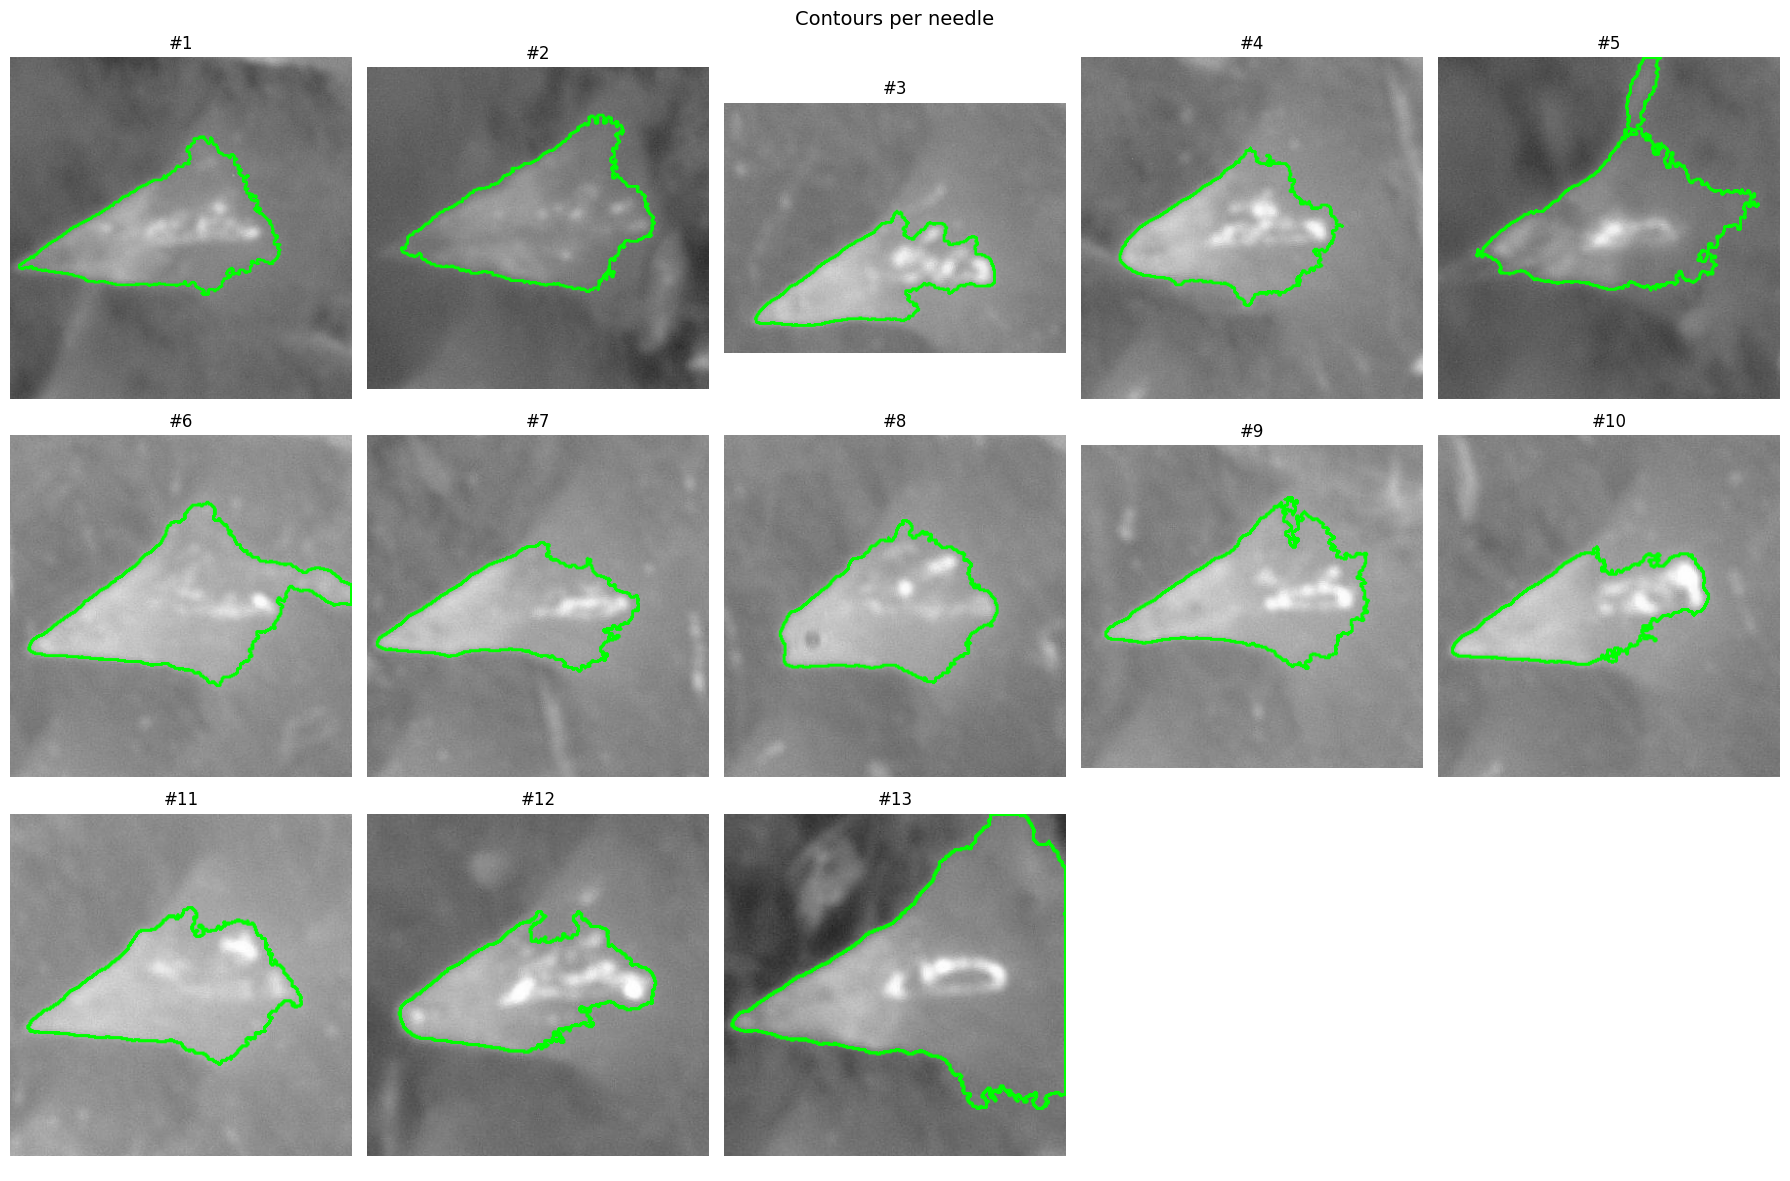

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for i, kp in enumerate(keypoints_filtered):
    x, y = int(kp.pt[0]), int(kp.pt[1])
    r = int(kp.size / 2) + 90
    
    x1, y1 = max(0, x-r), max(0, y-r)
    x2, y2 = min(img_cropped.shape[1], x+r), min(img_cropped.shape[0], y+r)
    crop = img_cropped[y1:y2, x1:x2]
    
    blur = cv2.GaussianBlur(crop, (5, 5), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 輪郭を描画
    vis = cv2.cvtColor(crop, cv2.COLOR_GRAY2BGR)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        cv2.drawContours(vis, [cnt], -1, (0, 255, 0), 2)
    
    axes[i].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"#{i+1}")
    axes[i].axis('off')

for j in range(len(keypoints_filtered), len(axes)):
    axes[j].axis('off')

plt.suptitle("Contours per needle", fontsize=14)
plt.tight_layout()
plt.show()

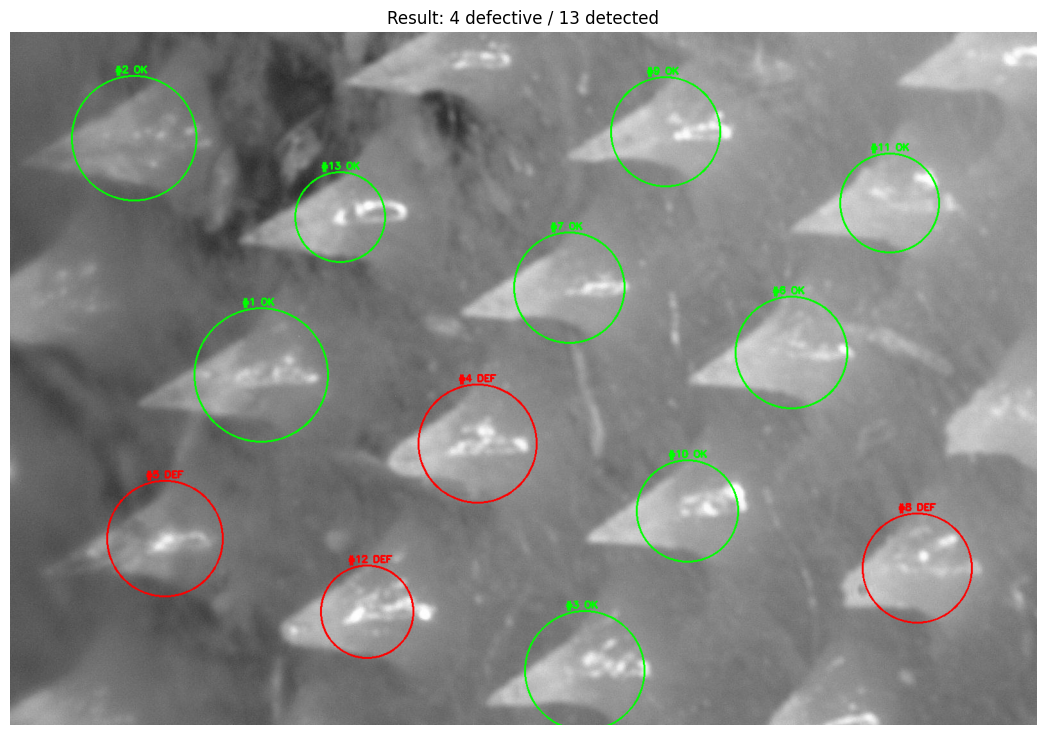

Defective needles: 4 -> needle #[4, 5, 8, 12]
Normal needles:    9


In [17]:
THRESHOLD = 0.5

# 判定
defective_detected = []
normal_detected = []

for r in results3:
    if r['taper_ratio'] is None:
        continue
    if r['taper_ratio'] >= THRESHOLD:
        defective_detected.append(r['id'])
    else:
        normal_detected.append(r['id'])

# 元画像に結果をオーバーレイ
img_final = cv2.cvtColor(img_cropped, cv2.COLOR_GRAY2BGR)

for r in results3:
    if r['taper_ratio'] is None:
        continue
    kp = keypoints_filtered[r['id'] - 1]
    x, y = int(kp.pt[0]), int(kp.pt[1])
    rad = int(kp.size / 2)
    
    if r['taper_ratio'] >= THRESHOLD:
        color = (0, 0, 255)   # 赤 = 欠損
        label = f"#{r['id']} DEF"
    else:
        color = (0, 255, 0)   # 緑 = 正常
        label = f"#{r['id']} OK"
    
    cv2.circle(img_final, (x, y), rad, color, 2)
    cv2.putText(img_final, label, (x - 30, y - rad - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title(f"Result: {len(defective_detected)} defective / {len(keypoints_filtered)} detected")
plt.axis('off')
plt.show()

print(f"Defective needles: {len(defective_detected)} -> needle #{defective_detected}")
print(f"Normal needles:    {len(normal_detected)}")